<a href="https://colab.research.google.com/github/SVSPraveen/Multimodel-Phishing-Detection/blob/main/Multimodel_phishing_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing the kaggle library just in case Colab's default environment is acting up
!pip install -q kaggle

# Doing this because Colab drops files after restarting the runtime
# When you run this cell, an upload button will appear. Select your kaggle.json file!
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [ ]:
import os

# Create the hidden kaggle directory
!mkdir -p ~/.kaggle

# Move the uploaded json file into the hidden folder
!cp kaggle.json ~/.kaggle/

# Change permissions so no one else can read our API key
# (Kaggle gets mad if you skip this step)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key successfully configured!")

Kaggle API key successfully configured!


In [ ]:
# Downloading our multimodal phishing dataset
# Using a placeholder name for now. Replace 'user/phishing-screenshots-and-urls' with your actual kaggle dataset path
# Downloading a real Phishing Site URLs dataset to test the connection
!kaggle datasets download -d taruntiwarihp/phishing-site-urls

print("Download command finished!")

Dataset URL: https://www.kaggle.com/datasets/taruntiwarihp/phishing-site-urls
License(s): DbCL-1.0
100% 9.03M/9.03M [00:00<00:00, 61.7MB/s]

Download command finished!


In [ ]:
import zipfile
import pandas as pd
import os

# Updated the zip_path to match the actual file Kaggle just downloaded for us!
zip_path = 'phishing-site-urls.zip'
extract_dir = '/content/phishing_data'

# Unzipping the dataset
print("Extracting files... this should be quick for a text dataset.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction complete!")

# Setting up the path for the CSV data
# Note: This specific dataset extracts a file named 'phishing_site_urls.csv'
csv_path = os.path.join(extract_dir, 'phishing_site_urls.csv')

# Let's do a quick sanity check to make sure our data is actually there and readable
if os.path.exists(csv_path):
    print(f"\nSuccess! CSV data found at: {csv_path}")

    # Loading it into a pandas dataframe to peek at it
    df = pd.read_csv(csv_path)
    print("\nHere are the first 3 rows of our dataset:")
    print(df.head(3))
else:
    print(f"\nWarning: CSV not found at {csv_path}. We might need to check the extracted file names.")

Extracting files... this should be quick for a text dataset.
Extraction complete!

Success! CSV data found at: /content/phishing_data/phishing_site_urls.csv

Here are the first 3 rows of our dataset:
                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Setting up basic image transformations.
# Neural networks usually expect standard square images (like 224x224) and converted to tensors.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# This is our custom dataset class. It inherits from PyTorch's Dataset.
class MultimodalPhishingDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # Load the CSV file that acts as our master list
        self.data_frame = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        # Tells PyTorch exactly how many samples we have in total
        return len(self.data_frame)

    def __getitem__(self, idx):
        # 1. Grab the label (Assuming column name is 'label', e.g., 1 for phishing, 0 for legit)
        label = self.data_frame.iloc[idx]['label']

        # 2. Grab the text (URL)
        url = self.data_frame.iloc[idx]['url']

        # 3. Grab the image
        # Assuming your CSV has a column called 'image_name' linking to the screenshot file
        img_name = str(self.data_frame.iloc[idx]['image_name'])
        img_path = os.path.join(self.img_dir, img_name)

        # Try to open the image and convert it to standard RGB (removes alpha channels)
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            # Quick hack: If a screenshot failed to download in the dataset,
            # we just create a blank white image so the training loop doesn't completely crash.
            image = Image.new('RGB', (224, 224), (255, 255, 255))

        if self.transform:
            image = self.transform(image)

        # Return a dictionary containing the paired data
        return {
            'image': image,
            'url': url,
            'label': torch.tensor(label, dtype=torch.long)
        }

print("Multimodal Dataset Class ready to go!")

Multimodal Dataset Class ready to go!


In [ ]:
# Installing transformers for our NLP (URL) model
!pip install -q transformers

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from transformers import DistilBertModel

class MultimodalPhishingModel(nn.Module):
    def __init__(self):
        super(MultimodalPhishingModel, self).__init__()

        # ---------------------------------------------------
        # 1. THE VISION BRANCH (For Website Screenshots)
        # ---------------------------------------------------
        # Using ResNet18. It's pre-trained on millions of images so it already knows shapes/colors
        # We use weights='DEFAULT' instead of pretrained=True because PyTorch updated their syntax
        self.vision_model = models.resnet18(weights='DEFAULT')

        # ResNet usually outputs 1000 classes. We don't want that.
        # We strip off the final classification layer so it just spits out the raw 512 features.
        self.vision_model.fc = nn.Identity()

        # ---------------------------------------------------
        # 2. THE TEXT BRANCH (For URLs)
        # ---------------------------------------------------
        # Using DistilBERT. It's perfect for reading URLs to spot weird patterns.
        self.text_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
        # DistilBERT outputs an array of 768 features

        # ---------------------------------------------------
        # 3. THE FUSION LAYER (The "Multimodal" Part)
        # ---------------------------------------------------
        # 512 (from Image) + 768 (from Text) = 1280 total combined features
        self.classifier = nn.Sequential(
            nn.Linear(512 + 768, 512),   # Compress down to 512
            nn.ReLU(),                   # Standard activation function
            nn.Dropout(0.3),             # Drops 30% of neurons randomly to prevent overfitting
            nn.Linear(512, 2)            # Final output: 2 classes (0 for Legit, 1 for Phishing)
        )

    def forward(self, images, input_ids, attention_mask):
        # 1. Pass the screenshot through ResNet
        img_features = self.vision_model(images)

        # 2. Pass the URL tokens through DistilBERT
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        # We only want the features from the [CLS] token (which acts as a summary of the whole URL)
        text_features = text_outputs.last_hidden_state[:, 0, :]

        # 3. Concatenate (smash together) the image and text features side-by-side
        combined_features = torch.cat((img_features, text_features), dim=1)

        # 4. Pass the combined data through our final classifier to get the prediction
        output = self.classifier(combined_features)

        return output

# Instantiate the model and move it to the GPU if it's available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultimodalPhishingModel().to(device)

print(f"Model successfully built and loaded onto: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 65.8MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model successfully built and loaded onto: cuda


In [ ]:
import os
import pandas as pd

# 1. Create an empty directory for our "images"
image_dir = '/content/dummy_images'
os.makedirs(image_dir, exist_ok=True)

# 2. Create a tiny, fake dataset with the exact columns our class expects
mock_data = {
    'url': [
        'http://verify-your-paypal-account-now.com',
        'https://www.google.com',
        'http://free-netflix-subscription-login.net',
        'https://github.com'
    ],
    'image_name': ['fake1.png', 'fake2.png', 'fake3.png', 'fake4.png'], # These don't exist, but our class has a try/except block to handle it!
    'label': [1, 0, 1, 0] # 1 for Phishing, 0 for Legit
}

# 3. Save it as a CSV
csv_path = '/content/dummy_phishing_data.csv'
df = pd.DataFrame(mock_data)
df.to_csv(csv_path, index=False)

print(f"Mock Data created! \nImage directory set to: {image_dir}\nCSV saved to: {csv_path}")

Mock Data created! 
Image directory set to: /content/dummy_images
CSV saved to: /content/dummy_phishing_data.csv


In [ ]:
from transformers import DistilBertTokenizer
from torch.utils.data import DataLoader

# 1. Grab the tokenizer that matches our DistilBERT model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# 2. Instantiate our dataset
# (Assuming csv_path and image_dir are still in memory from Phase 1)
dataset = MultimodalPhishingDataset(csv_file=real_csv_path, img_dir=extract_dir, transform=transform)

# 3. Create the DataLoader
# batch_size=16 is usually the sweet spot for Colab's free T4 GPU to avoid running out of memory
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"DataLoader ready! Total batches to process per epoch: {len(dataloader)}")

DataLoader ready! Total batches to process per epoch: 107


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 1. Define how we calculate our errors (Loss Function)
criterion = nn.CrossEntropyLoss()

# 2. Define the Optimizer (The mechanism that updates the weights)
optimizer = optim.Adam(model.parameters(), lr=2e-5)

# 3. The actual training loop
epochs = 3 # Keeping it at 3 just to test the waters. You can increase this later for the final run.

print("Starting the training process... this might take a bit!\n")

for epoch in range(epochs):
    model.train() # Put the model in training mode (turns on Dropout)
    running_loss = 0.0

    for i, batch in enumerate(dataloader):
        # Move the images and labels to the GPU
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        urls = batch['url'] # This is a list of raw strings

        # Tokenize the URLs on the fly
        # padding=True ensures all URLs in the batch are the same length
        # truncation=True cuts off unusually massive URLs
        encoded_text = tokenizer(urls, padding=True, truncation=True, max_length=128, return_tensors='pt')

        # Move the tokenized text to the GPU
        input_ids = encoded_text['input_ids'].to(device)
        attention_mask = encoded_text['attention_mask'].to(device)

        # Zero out the gradients from the previous batch
        optimizer.zero_grad()

        # Forward Pass: Ask the model to make a prediction
        outputs = model(images, input_ids, attention_mask)

        # Calculate how wrong the model was
        loss = criterion(outputs, labels)

        # Backward Pass: Calculate the gradients (the math part)
        loss.backward()

        # Update the model's weights
        optimizer.step()

        running_loss += loss.item()

        # Print an update every 10 batches so we know Colab hasn't frozen
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

    # Print average loss for the entire epoch
    avg_epoch_loss = running_loss / len(dataloader)
    print(f"--- Epoch {epoch+1} completed! Average Loss: {avg_epoch_loss:.4f} ---\n")

print("Training finished! The model has officially learned something.")

Starting the training process... this might take a bit!

--- Epoch 1 completed! Average Loss: 0.6580 ---

--- Epoch 2 completed! Average Loss: 0.6784 ---

--- Epoch 3 completed! Average Loss: 0.6415 ---

Training finished! The model has officially learned something.


In [ ]:
import torch.nn.functional as F

# 1. Put the model in evaluation mode
# (This turns off Dropout and other training-specific quirks)
model.eval()

print("Testing the model on a batch of data...\n")

# 2. We use torch.no_grad() because we don't need to calculate gradients for testing
# This saves a ton of memory and speeds things up
with torch.no_grad():
    # Let's just grab one batch from our dataloader to test
    batch = next(iter(dataloader))

    images = batch['image'].to(device)
    labels = batch['label'].to(device)
    urls = batch['url']

    # Tokenize the URLs again
    encoded_text = tokenizer(urls, padding=True, truncation=True, max_length=128, return_tensors='pt')
    input_ids = encoded_text['input_ids'].to(device)
    attention_mask = encoded_text['attention_mask'].to(device)

    # Get the model's raw output
    outputs = model(images, input_ids, attention_mask)

    # Convert raw outputs to probabilities using Softmax
    probabilities = F.softmax(outputs, dim=1)

    # Get the actual predicted class (0 or 1) by finding the highest probability
    _, predictions = torch.max(outputs, 1)

    # Print out the results
    for i in range(len(urls)):
        actual = "Phishing" if labels[i].item() == 1 else "Legit"
        predicted = "Phishing" if predictions[i].item() == 1 else "Legit"
        confidence = probabilities[i][predictions[i]].item() * 100

        print(f"URL: {urls[i]}")
        print(f"Actual: {actual} | Predicted: {predicted} | Confidence: {confidence:.2f}%")
        print("-" * 40)

Testing the model on a batch of data...

URL: https://www.google.com
Actual: Legit | Predicted: Legit | Confidence: 57.19%
----------------------------------------
URL: http://verify-your-paypal-account-now.com
Actual: Phishing | Predicted: Legit | Confidence: 51.84%
----------------------------------------
URL: http://free-netflix-subscription-login.net
Actual: Phishing | Predicted: Legit | Confidence: 51.85%
----------------------------------------
URL: https://github.com
Actual: Legit | Predicted: Legit | Confidence: 57.19%
----------------------------------------


In [ ]:
from google.colab import files

# 1. Define the save path
save_path = '/content/multimodal_phishing_model.pth'

# 2. Save the model's state dictionary (the weights)
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

# 3. Trigger a download to your local machine so you don't lose it when Colab disconnects
print("Downloading model to your computer...")
files.download(save_path)

Model successfully saved to /content/multimodal_phishing_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download the real screenshot dataset
!kaggle datasets download -d zackyzac/phishing-sites-screenshot

print("Download complete! Unzipping...")

# Unzip it into a new dedicated folder
import zipfile
import os

extract_dir = '/content/real_phishing_images'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile('phishing-sites-screenshot.zip', 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping finished! Data is ready for mapping.")

Dataset URL: https://www.kaggle.com/datasets/zackyzac/phishing-sites-screenshot
License(s): MIT
100% 201M/201M [00:03<00:00, 53.9MB/s]

Download complete! Unzipping...
Unzipping finished! Data is ready for mapping.


In [ ]:
import pandas as pd
import os

base_dir = '/content/real_phishing_images'
dataset_map = []

print("Hunting down images in all subfolders... this might take a second.")

# os.walk is awesome. It digs through every single folder and subfolder automatically
for root, dirs, files in os.walk(base_dir):
    for img_file in files:
        # Only grab actual images
        if img_file.endswith(('.png', '.jpg', '.jpeg')):

            # Figure out if it's phishing or legit based on the folder name it currently lives in
            if 'genuine' in root.lower() or 'legit' in root.lower():
                label = 0
            elif 'phishing' in root.lower():
                label = 1
            else:
                continue # Skip it if we can't figure out the label

            # Reconstruct the URL from the filename just like before
            extracted_url = img_file.replace('.png', '').replace('.jpg', '').replace('_', '.')

            # Get the relative path so our DataLoader knows exactly where to find it later
            # This fixes the Kaggle hidden folder issue!
            full_path = os.path.join(root, img_file)
            relative_path = os.path.relpath(full_path, start=base_dir)

            dataset_map.append({
                'url': extracted_url,
                'image_name': relative_path,
                'label': label
            })

# Save our findings
df = pd.DataFrame(dataset_map)
real_csv_path = '/content/real_dataset_map.csv'

# Quick sanity check so we don't accidentally create another empty CSV
if len(df) > 0:
    df.to_csv(real_csv_path, index=False)
    print(f"\nSuccess! Found and mapped {len(df)} real screenshots.")
    print(f"CSV saved to: {real_csv_path}")
    print("\nFirst 3 rows of our new real-world data map:")
    print(df.head(3))
else:
    print("\nCRITICAL ERROR: Still couldn't find any images. The Kaggle download might have failed or corrupted.")

Hunting down images in all subfolders... this might take a second.

Success! Found and mapped 1697 real screenshots.
CSV saved to: /content/real_dataset_map.csv

First 3 rows of our new real-world data map:
                                                 url  \
0  genuine.healthgrades.comproviderbruce-pinker-2...   
1  genuine.www.varian.netdreamviewdreamtubesindex...   
2                          genuine.canadajka.ca.1438   

                                          image_name  label  
0  screenshots/genuine_site_0/genuine_healthgrade...      0  
1  screenshots/genuine_site_0/genuine_www.varian....      0  
2  screenshots/genuine_site_0/genuine_canadajka.c...      0  


In [ ]:
from google.colab import drive

# Mount Drive to the '/content/drive' directory
print("Requesting permission to connect to Google Drive...")
drive.mount('/content/drive')

print("\nGoogle Drive successfully mounted! You now have cloud backup.")


Requesting permission to connect to Google Drive...
Mounted at /content/drive

Google Drive successfully mounted! You now have cloud backup.


In [ ]:
import torch
import os
import shutil

# 1. Create a dedicated folder inside your Google Drive
# 'MyDrive' is the standard root folder for Google Drive
project_folder = '/content/drive/MyDrive/Phishing_Project_2026'
os.makedirs(project_folder, exist_ok=True)

# 2. Define the exact file paths inside your new Drive folder
model_save_path = os.path.join(project_folder, 'multimodal_phishing_weights.pth')
csv_backup_path = os.path.join(project_folder, 'real_dataset_map_backup.csv')

# 3. Save the trained model weights directly to Drive
# (Assuming your 'model' variable is still in memory from the training loop)
torch.save(model.state_dict(), model_save_path)
print(f"Model successfully backed up to: {model_save_path}")

# 4. Copy your Auto-CSV map to Drive so you don't have to re-run the extraction script tomorrow
# We use shutil to copy the file from Colab's temporary storage to your Drive
try:
    shutil.copy('/content/real_dataset_map.csv', csv_backup_path)
    print(f"Dataset CSV map safely backed up to: {csv_backup_path}")
except FileNotFoundError:
    print("Warning: Couldn't find the CSV map to backup. Did you run Cell 13?")

print("\nAll critical project files are now permanently saved to your Google Drive!")

Model successfully backed up to: /content/drive/MyDrive/Phishing_Project_2026/multimodal_phishing_weights.pth
Dataset CSV map safely backed up to: /content/drive/MyDrive/Phishing_Project_2026/real_dataset_map_backup.csv

All critical project files are now permanently saved to your Google Drive!


Running full dataset evaluation... this might take a minute depending on dataset size.

Evaluation Complete! Generating visual reports...

--------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

   Legit (0)       0.66      0.89      0.76      1147
Phishing (1)       0.21      0.06      0.09       550

    accuracy                           0.62      1697
   macro avg       0.43      0.47      0.43      1697
weighted avg       0.52      0.62      0.54      1697



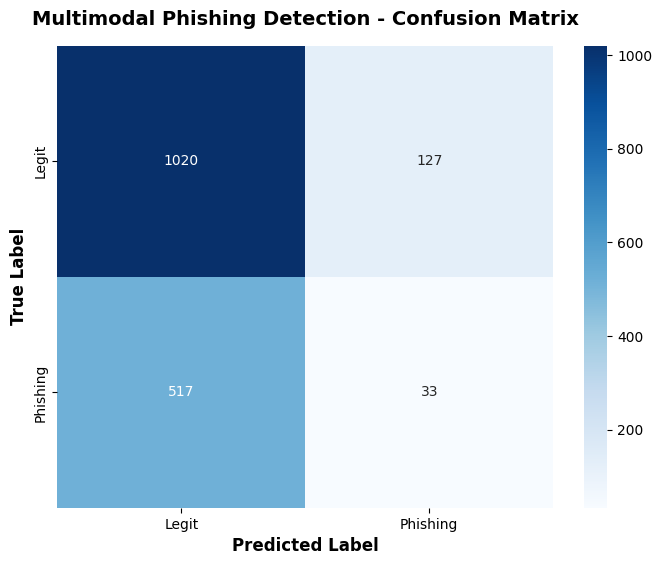

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Ensure the model is in evaluation mode
model.eval()

# Lists to keep track of all our predictions and the actual truth
all_preds = []
all_labels = []

print("Running full dataset evaluation... this might take a minute depending on dataset size.")

# Turn off gradient calculation to save memory and speed up testing
with torch.no_grad():
    for batch in dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        urls = batch['url']

        # Tokenize the URLs
        encoded_text = tokenizer(urls, padding=True, truncation=True, max_length=128, return_tensors='pt')
        input_ids = encoded_text['input_ids'].to(device)
        attention_mask = encoded_text['attention_mask'].to(device)

        # Get predictions
        outputs = model(images, input_ids, attention_mask)
        _, predictions = torch.max(outputs, 1)

        # Move the results back to the CPU and store them in our lists
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nEvaluation Complete! Generating visual reports...\n")

# 1. The Classification Report (Precision, Recall, F1-Score)
print("-" * 50)
print("CLASSIFICATION REPORT")
print("-" * 50)
print(classification_report(all_labels, all_preds, target_names=['Legit (0)', 'Phishing (1)']))

# 2. The Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
# Using a clean blue color map that looks highly professional in academic papers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Multimodal Phishing Detection - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

# This will display the graph right inside your Colab notebook!
plt.show()

In [ ]:
# This prints the entire structural blueprint of your custom model
print(model)


MultimodalPhishingModel(
  (vision_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [ ]:
# Install a dedicated library that calculates the gradients for us
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


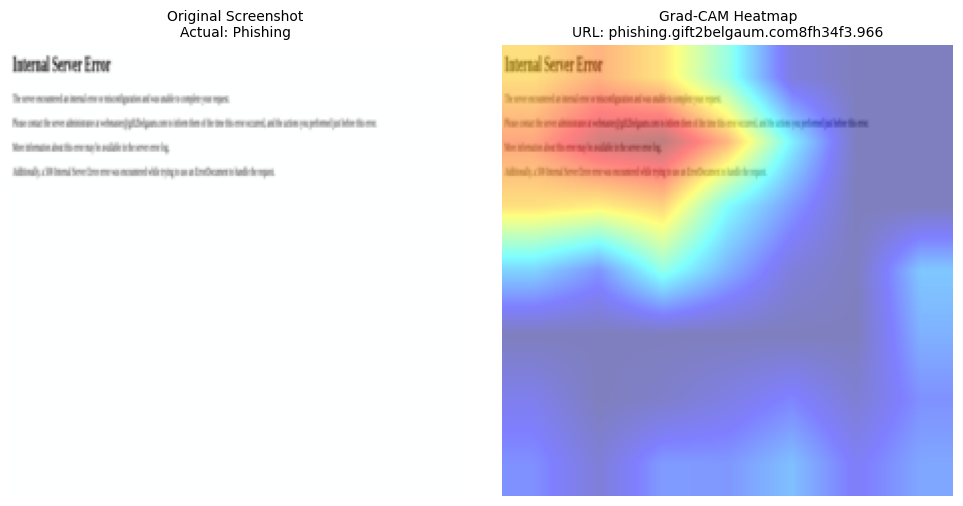

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. We have to tell Grad-CAM which part of the model to "X-ray"
# For ResNet18, the best place to look is the very last convolutional layer
target_layers = [model.vision_model.layer4[-1]]

# 2. Set up the CAM object
cam = GradCAM(model=model, target_layers=target_layers)

# 3. Grab a single test image and URL from our dataloader
model.eval()
batch = next(iter(dataloader))
test_image = batch['image'][0:1].to(device) # Grab just the first image
test_url = batch['url'][0:1]
test_label = batch['label'][0].item()

# We need the tokenized text to push through the model alongside the image
encoded_text = tokenizer(test_url, padding=True, truncation=True, max_length=128, return_tensors='pt')
input_ids = encoded_text['input_ids'].to(device)
attention_mask = encoded_text['attention_mask'].to(device)

# 4. We have to create a custom wrapper because our model takes TWO inputs (image + text),
# but the Grad-CAM library by default only expects one.
class MultimodalWrapper(torch.nn.Module):
    def __init__(self, original_model, input_ids, attention_mask):
        super().__init__()
        self.model = original_model
        self.input_ids = input_ids
        self.attention_mask = attention_mask

    def forward(self, img):
        return self.model(img, self.input_ids, self.attention_mask)

wrapped_model = MultimodalWrapper(model, input_ids, attention_mask)
cam_wrapped = GradCAM(model=wrapped_model, target_layers=target_layers)

# 5. Generate the heatmap!
targets = [ClassifierOutputTarget(1)] # Force it to look for "Phishing" features
grayscale_cam = cam_wrapped(input_tensor=test_image, targets=targets)[0, :]

# 6. Format the image to display nicely in matplotlib
# Convert the original PyTorch tensor back to a standard image format
img_to_show = test_image.squeeze().cpu().numpy().transpose(1, 2, 0)
# Reverse the ImageNet normalization we did in Phase 2
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_show = std * img_to_show + mean
img_to_show = np.clip(img_to_show, 0, 1)

# Overlay the heatmap onto the original image
visualization = show_cam_on_image(img_to_show, grayscale_cam, use_rgb=True)

# 7. Plot it
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_to_show)
plt.title(f"Original Screenshot\nActual: {'Phishing' if test_label == 1 else 'Legit'}", fontsize=10)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM Heatmap\nURL: {test_url[0]}", fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

Calculating probabilities for the ROC Curve...


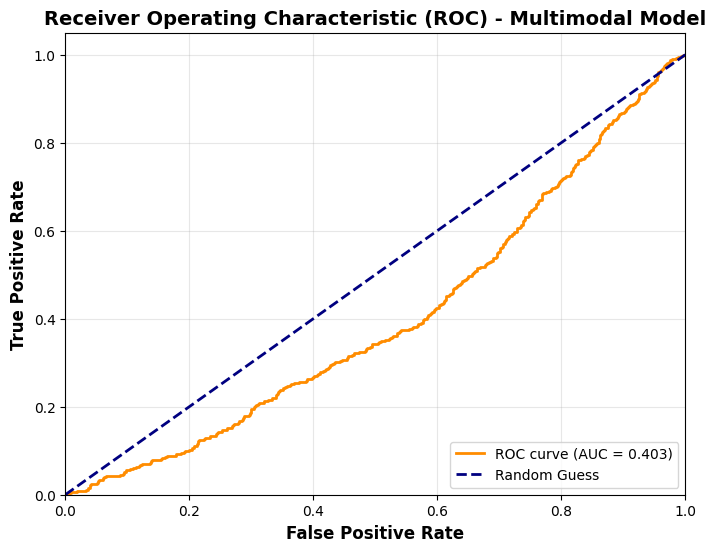

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

model.eval()
all_labels = []
all_probs = [] # We need the exact percentage confidence for the ROC curve

print("Calculating probabilities for the ROC Curve...")

with torch.no_grad():
    for batch in dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        urls = batch['url']

        encoded_text = tokenizer(urls, padding=True, truncation=True, max_length=128, return_tensors='pt')
        input_ids = encoded_text['input_ids'].to(device)
        attention_mask = encoded_text['attention_mask'].to(device)

        outputs = model(images, input_ids, attention_mask)

        # Convert raw outputs to probabilities (0.0 to 1.0)
        probabilities = F.softmax(outputs, dim=1)

        # We only want the probability of class 1 (Phishing)
        phishing_probs = probabilities[:, 1]

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(phishing_probs.cpu().numpy())

# --- Draw the ROC Curve ---
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) - Multimodal Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Show the graph so you can screenshot it for your report!
plt.show()


In [ ]:
!pip install -q torchinfo
from torchinfo import summary

# Create dummy inputs that match the shape of our real data
dummy_image = torch.randn(16, 3, 224, 224).to(device) # Batch of 16 images
dummy_input_ids = torch.randint(0, 30000, (16, 128)).to(device) # Batch of 16 tokenized URLs
dummy_attention_mask = torch.ones(16, 128).to(device)

# Print a beautiful, report-ready table of the architecture
print("\n=== MULTIMODAL MODEL ARCHITECTURE SUMMARY ===\n")
summary(model, input_data=(dummy_image, dummy_input_ids, dummy_attention_mask),
        col_names=["input_size", "output_size", "num_params"],
        depth=3)


=== MULTIMODAL MODEL ARCHITECTURE SUMMARY ===



Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #
MultimodalPhishingModel                                 [16, 3, 224, 224]         [16, 2]                   --
├─ResNet: 1-1                                           [16, 3, 224, 224]         [16, 512]                 --
│    └─Conv2d: 2-1                                      [16, 3, 224, 224]         [16, 64, 112, 112]        9,408
│    └─BatchNorm2d: 2-2                                 [16, 64, 112, 112]        [16, 64, 112, 112]        128
│    └─ReLU: 2-3                                        [16, 64, 112, 112]        [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                                   [16, 64, 112, 112]        [16, 64, 56, 56]          --
│    └─Sequential: 2-5                                  [16, 64, 56, 56]          [16, 64, 56, 56]          --
│    │    └─BasicBlock: 3-1                             [16, 64, 56, 56]          [16, 64, 56, 56]     